### Data Loading and Sampling

In [1]:
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
dataset_path = os.getenv("DATASET_PATH", "")
dataset_percent = os.getenv("DATASET_PERCENT", 0.01)

# Load the full dataset to get the total number of rows
df_full = pd.read_csv(dataset_path)

# Calculate 1% of the total number of rows
sample_size = int(len(df_full) * float(dataset_percent))

# Sample 1% of the DataFrame and assign it to df_incidents
df_incidents = df_full.sample(n=sample_size, random_state=42).reset_index(drop=True)

print(f"Loaded {float(dataset_percent)*100}% of the dataset. New 'df_incidents' with shape: {df_incidents.shape}")
df_incidents

Loaded 1.0% of the dataset. New 'df_incidents' with shape: (478, 2)


,Document,Topic_group
0,issue with server process sent tuesday issue w...,Hardware
1,new purchase po wednesday february purchase po...,Purchase
2,oracle pas urgent re we updated rights query h...,Hardware
3,new starter access thursday pm re starter form...,HR Support
4,new phone phone hi taken work mobile phone spe...,Hardware
...,...,...
473,issues rename issues hi please be informed hav...,Hardware
474,new purchase po pm purchase po dear purchased ...,Purchase
475,change oracle change dear ask change employees...,Miscellaneous
476,accessible from queries tuesday re accessible ...,HR Support


### Feature Engineering (SBERT Embeddings & PCA)

In [3]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

# 1. Initialize SBERT model (Dense Vector Embeddings)
print("Loading SBERT model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Generate Semantic Embeddings
print("Generating semantic embeddings (this may take a moment)...")
embeddings = model.encode(df_incidents['Document'].tolist(), show_progress_bar=True)

# 3. Dimensionality Reduction (PCA)
# Compressing 384 dimensions to 10 components to help clustering
print("Applying PCA reduction...")
pca = PCA(n_components=10, random_state=42)
X = pca.fit_transform(embeddings)

# Define the target variable y
y = df_incidents['Topic_group']

print(f"Original embedding shape: {embeddings.shape}")
print(f"Reduced X shape (PCA): {X.shape}")
print(f"Shape of y (target): {y.shape}")

e:\AIML\GoogleAntigravity_proj\ColabNotebooks\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading SBERT model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6505.24it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating semantic embeddings (this may take a moment)...


Batches: 100%|██████████| 15/15 [00:08<00:00,  1.67it/s]

Applying PCA reduction...
Original embedding shape: (478, 384)
Reduced X shape (PCA): (478, 10)
Shape of y (target): (478,)


### Data Splitting

In [4]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Print the shapes of the resulting sets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (334, 10)
Shape of X_test: (144, 10)
Shape of y_train: (334,)
Shape of y_test: (144,)


### K-Means Clustering

In [5]:
from sklearn.cluster import KMeans

# Instantiate KMeans model with n_clusters=5 and random_state=42
kmeans_model_sampled = KMeans(n_clusters=5, random_state=42, n_init='auto')

# Fit the KMeans model to the TF-IDF vectorized data (X) from the 1% sample
kmeans_model_sampled.fit(X)

# Add the cluster labels as a new column to the df_incidents DataFrame (from the 1% sample)
df_incidents['cluster_label'] = kmeans_model_sampled.labels_

# Print the value counts of the 'cluster_label' column
print("Distribution of incidents across clusters (1% Sampled Data):")
print(df_incidents['cluster_label'].value_counts())

Distribution of incidents across clusters (1% Sampled Data):
cluster_label
1    117
2    113
0     93
3     81
4     74
Name: count, dtype: int64


### Silhouette Score

In [6]:
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score
silhouette_avg = silhouette_score(X, kmeans_model_sampled.labels_)

print(f"The average silhouette_score for the clusters is: {silhouette_avg:.4f}")

The average silhouette_score for the clusters is: 0.1038


### Cluster Prioritization

In [7]:
def get_most_frequent(series):
    if series.isnull().all():
        return 'Not Available'
    counts = series.astype(str).value_counts(dropna=False)
    if 'nan' in counts.index:
        counts = counts.drop('nan')
    if counts.empty:
        return 'Not Available'
    return counts.idxmax()

# Group by 'cluster_label' and calculate summary statistics for the 1% sampled data
cluster_metrics_sampled = df_incidents.groupby('cluster_label').agg(
    incident_volume=('Document', 'size'),
    most_frequent_topic_group=('Topic_group', get_most_frequent)
).reset_index()

# Prioritize clusters by sorting based on 'incident_volume' in descending order
prioritized_clusters_sampled = cluster_metrics_sampled.sort_values(by='incident_volume', ascending=False)

print("Prioritized Clusters based on Incident Volume (1% Sampled Data):")
prioritized_clusters_sampled

Prioritized Clusters based on Incident Volume (1% Sampled Data):


,cluster_label,incident_volume,most_frequent_topic_group
1,1,117,Miscellaneous
2,2,113,Access
0,0,93,Hardware
3,3,81,HR Support
4,4,74,Hardware


### Knowledge Article (KA) Generation

In [8]:
knowledge_articles_sampled = []

for index, row in prioritized_clusters_sampled.iterrows():
    cluster_label = row['cluster_label']
    incident_volume = row['incident_volume']
    most_frequent_topic_group = row['most_frequent_topic_group']

    # Define placeholder values for common themes not directly available in df_incidents
    most_frequent_root_cause = "Not Specified"
    most_frequent_issue_type = "Not Available"
    recommended_remediation_steps = "Not Available"

    # Construct the Knowledge Article string
    ka_string = f"""Knowledge Article for Cluster {cluster_label} (1% Sampled Data):
    - Incident Volume: {incident_volume}
    - Most Frequent Topic Group: {most_frequent_topic_group}
    - Most Common Root Cause: {most_frequent_root_cause}
    - Most Common Issue Type: {most_frequent_issue_type}
    - Recommended Remediation Steps: {recommended_remediation_steps}
    """
    knowledge_articles_sampled.append(ka_string)

# Print each generated Knowledge Article
print("Generated Knowledge Articles (KAs) for 1% Sampled Data:")
for ka in knowledge_articles_sampled:
    print(ka)

Generated Knowledge Articles (KAs) for 1% Sampled Data:
Knowledge Article for Cluster 1 (1% Sampled Data):
    - Incident Volume: 117
    - Most Frequent Topic Group: Miscellaneous
    - Most Common Root Cause: Not Specified
    - Most Common Issue Type: Not Available
    - Recommended Remediation Steps: Not Available
    
Knowledge Article for Cluster 2 (1% Sampled Data):
    - Incident Volume: 113
    - Most Frequent Topic Group: Access
    - Most Common Root Cause: Not Specified
    - Most Common Issue Type: Not Available
    - Recommended Remediation Steps: Not Available
    
Knowledge Article for Cluster 0 (1% Sampled Data):
    - Incident Volume: 93
    - Most Frequent Topic Group: Hardware
    - Most Common Root Cause: Not Specified
    - Most Common Issue Type: Not Available
    - Recommended Remediation Steps: Not Available
    
Knowledge Article for Cluster 3 (1% Sampled Data):
    - Incident Volume: 81
    - Most Frequent Topic Group: HR Support
    - Most Common Root Cause:

### Enterprise Knowledge Graph (EKG) Construction

In [9]:
import networkx as nx

# 1. Initialize an empty graph for the sampled data
EKG_sampled = nx.Graph()

# 2. Add nodes for each incident from the 1% sampled df_incidents
for index, row in df_incidents.iterrows():
    incident_id = f"incident_{index}"
    EKG_sampled.add_node(incident_id, type='incident', Document=row['Document'], Topic_group=row['Topic_group'], cluster_label=row['cluster_label'])

# 3. Add nodes for each cluster from the prioritized_clusters_sampled
for index, row in prioritized_clusters_sampled.iterrows():
    cluster_id = f"cluster_{int(row['cluster_label'])}"
    EKG_sampled.add_node(cluster_id, type='cluster', incident_volume=row['incident_volume'], most_frequent_topic_group=row['most_frequent_topic_group'])

# 4. Add nodes for each unique 'Topic_group' from the 1% sampled df_incidents
unique_topic_groups_sampled = df_incidents['Topic_group'].unique()
for topic in unique_topic_groups_sampled:
    EKG_sampled.add_node(topic, type='Topic_group')

# 5. Add nodes for each generated Knowledge Article (from knowledge_articles_sampled)
ka_mapping_sampled = {}
for i, ka_text in enumerate(knowledge_articles_sampled):
    # Extract cluster label from the KA text to link it back
    ka_cluster_label = int(ka_text.split('Cluster ')[1].split(' ')[0])
    ka_id = f"KA_{ka_cluster_label}"
    EKG_sampled.add_node(ka_id, type='knowledge_article', text=ka_text)
    ka_mapping_sampled[ka_cluster_label] = ka_id

# 6. Add edges connecting each incident node to its corresponding cluster node
for index, row in df_incidents.iterrows():
    incident_id = f"incident_{index}"
    cluster_id = f"cluster_{int(row['cluster_label'])}"
    EKG_sampled.add_edge(incident_id, cluster_id, relationship='BELONGS_TO_CLUSTER')

# 7. Add edges connecting each incident node to its 'Topic_group' node
for index, row in df_incidents.iterrows():
    incident_id = f"incident_{index}"
    topic_group = row['Topic_group']
    EKG_sampled.add_edge(incident_id, topic_group, relationship='HAS_TOPIC')

# 8. Add edges connecting each cluster node to its 'most_frequent_topic_group' node
for index, row in prioritized_clusters_sampled.iterrows():
    cluster_id = f"cluster_{int(row['cluster_label'])}"
    most_frequent_topic = row['most_frequent_topic_group']
    EKG_sampled.add_edge(cluster_id, most_frequent_topic, relationship='DOMINANT_TOPIC')

# 9. Add edges connecting each cluster node to its corresponding Knowledge Article node
for index, row in prioritized_clusters_sampled.iterrows():
    cluster_label = row['cluster_label']
    cluster_id = f"cluster_{int(cluster_label)}"
    if cluster_label in ka_mapping_sampled:
        ka_id = ka_mapping_sampled[cluster_label]
        EKG_sampled.add_edge(cluster_id, ka_id, relationship='HAS_KNOWLEDGE_ARTICLE')

# Print the number of nodes and edges in the constructed EKG
print(f"Enterprise Knowledge Graph (1% Sampled Data) created with {EKG_sampled.number_of_nodes()} nodes and {EKG_sampled.number_of_edges()} edges.")

Enterprise Knowledge Graph (1% Sampled Data) created with 496 nodes and 966 edges.


In [10]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

# Calculate Davies-Bouldin Index
davies_bouldin = davies_bouldin_score(X, kmeans_model_sampled.labels_)
print(f"The Davies-Bouldin Index for the clusters is: {davies_bouldin:.4f}")

The Davies-Bouldin Index for the clusters is: 2.2622


In [11]:
# Calculate Calinski-Harabasz Index
calinski_harabasz = calinski_harabasz_score(X, kmeans_model_sampled.labels_)
print(f"The Calinski-Harabasz Index for the clusters is: {calinski_harabasz:.4f}")

The Calinski-Harabasz Index for the clusters is: 45.8520


In [12]:
# Calculate Inertia (Sum of Squared Distances)
inertia = kmeans_model_sampled.inertia_
print(f"The Inertia (Sum of Squared Distances) for the clusters is: {inertia:.4f}")

The Inertia (Sum of Squared Distances) for the clusters is: 77.3475


### EKG Visualization (Subset)

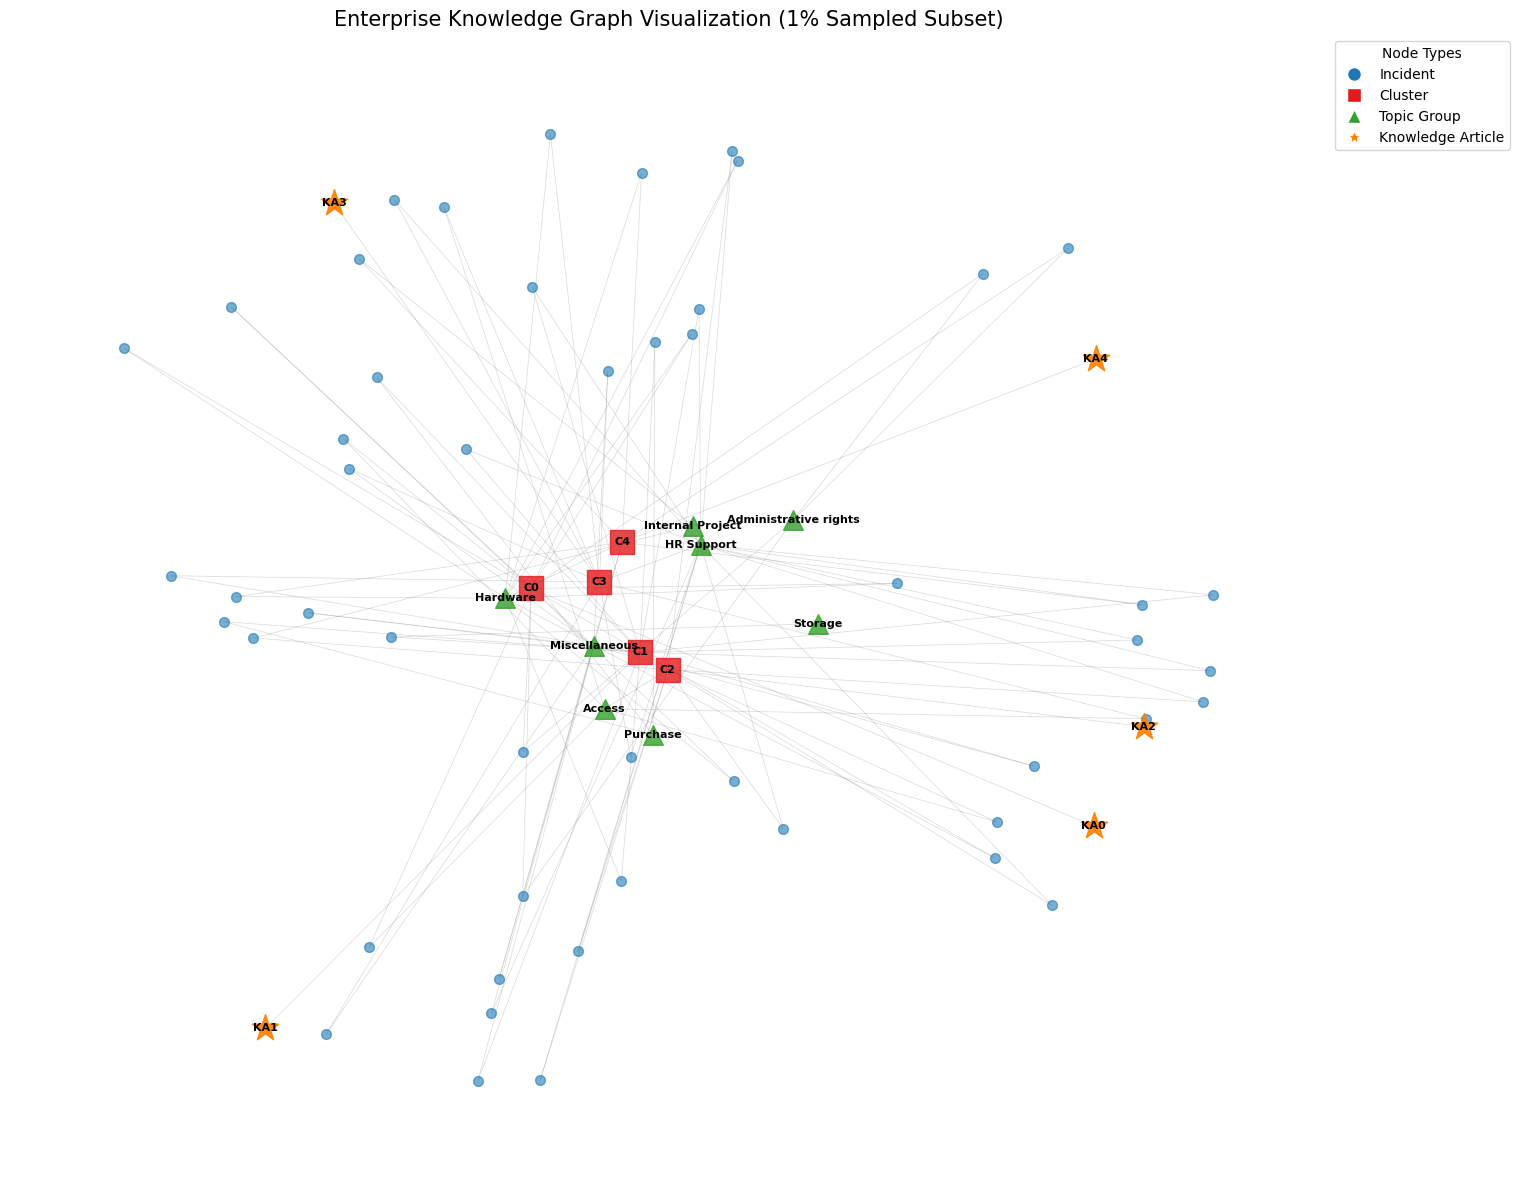

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define node colors for different node types
node_colors = {
    'incident': '#1f78b4',          # Blue
    'cluster': '#e31a1c',           # Red
    'Topic_group': '#33a02c',       # Green
    'knowledge_article': '#ff7f00'  # Orange
}

# 2. Define node shapes for different node types
node_shapes = {
    'incident': 'o',  # Circle
    'cluster': 's',   # Square
    'Topic_group': '^', # Triangle up
    'knowledge_article': '*' # Star
}

# Get all nodes by type from EKG_sampled
incident_nodes_sampled = [n for n, attr in EKG_sampled.nodes(data=True) if attr['type'] == 'incident']
cluster_nodes_sampled = [n for n, attr in EKG_sampled.nodes(data=True) if attr['type'] == 'cluster']
topic_group_nodes_sampled = [n for n, attr in EKG_sampled.nodes(data=True) if attr['type'] == 'Topic_group']
ka_nodes_sampled = [n for n, attr in EKG_sampled.nodes(data=True) if attr['type'] == 'knowledge_article']

# Sample a small number of incident nodes for visualization
sample_size = 50  # Adjust as needed
np.random.seed(42) # for reproducibility
if len(incident_nodes_sampled) > sample_size:
    sampled_incident_nodes_to_draw = list(np.random.choice(incident_nodes_sampled, sample_size, replace=False))
else:
    sampled_incident_nodes_to_draw = incident_nodes_sampled

# Combine nodes for visualization
nodes_to_draw_sampled = sampled_incident_nodes_to_draw + cluster_nodes_sampled + topic_group_nodes_sampled + ka_nodes_sampled

# Create a subgraph containing only the nodes we want to draw and their connecting edges
subgraph_sampled = EKG_sampled.subgraph(nodes_to_draw_sampled)

# 3. Define a layout for the graph
# Using the full graph for layout calculation might distribute nodes better,
# then we filter positions for our subgraph.
pos_sampled = nx.spring_layout(EKG_sampled, k=0.5, iterations=50, seed=42) # Calculate layout for the full sampled graph

# Filter positions for the nodes we want to draw
pos_subgraph_sampled = {node: pos_sampled[node] for node in subgraph_sampled.nodes() if node in pos_sampled}

# 4. Create a new figure and axes for the plot
plt.figure(figsize=(18, 12))
ax = plt.gca()
ax.axis('off') # Hide axes

# 5. Draw nodes with specific colors and shapes
# Draw incidents
incident_sub_nodes_to_draw = [n for n in sampled_incident_nodes_to_draw if n in subgraph_sampled.nodes()]
nx.draw_networkx_nodes(subgraph_sampled, pos_subgraph_sampled, nodelist=incident_sub_nodes_to_draw,
                       node_color=node_colors['incident'], node_shape=node_shapes['incident'],
                       node_size=50, alpha=0.6, label='Incident')

# Draw clusters
nx.draw_networkx_nodes(subgraph_sampled, pos_subgraph_sampled, nodelist=cluster_nodes_sampled,
                       node_color=node_colors['cluster'], node_shape=node_shapes['cluster'],
                       node_size=300, alpha=0.8, label='Cluster')

# Draw Topic Groups
nx.draw_networkx_nodes(subgraph_sampled, pos_subgraph_sampled, nodelist=topic_group_nodes_sampled,
                       node_color=node_colors['Topic_group'], node_shape=node_shapes['Topic_group'],
                       node_size=200, alpha=0.8, label='Topic Group')

# Draw Knowledge Articles
nx.draw_networkx_nodes(subgraph_sampled, pos_subgraph_sampled, nodelist=ka_nodes_sampled,
                       node_color=node_colors['knowledge_article'], node_shape=node_shapes['knowledge_article'],
                       node_size=400, alpha=0.9, label='Knowledge Article')

# Draw node labels for clusters, topic groups, and KAs (incidents are too many to label)
node_labels_sampled = {node: node.replace('cluster_', 'C').replace('Topic_group', 'TG').replace('KA_', 'KA')
                       for node in subgraph_sampled.nodes()
                       if subgraph_sampled.nodes[node]['type'] in ['cluster', 'Topic_group', 'knowledge_article']}
nx.draw_networkx_labels(subgraph_sampled, pos_subgraph_sampled, labels=node_labels_sampled, font_size=8, font_weight='bold')

# 6. Draw edges
nx.draw_networkx_edges(subgraph_sampled, pos_subgraph_sampled, edge_color='gray', alpha=0.3, width=0.5)

# 7. Add a legend to the plot
from matplotlib.lines import Line2D
legend_elements = []
for node_type, color in node_colors.items():
    shape = node_shapes[node_type]
    legend_elements.append(Line2D([0], [0], marker=shape, color='w', label=node_type.replace('_', ' ').title(),
                                      markerfacecolor=color, markersize=10))

ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1), title="Node Types")

# 8. Set the title of the plot
plt.title("Enterprise Knowledge Graph Visualization (1% Sampled Subset)", size=15)

# Adjust layout to prevent legend from overlapping with the plot
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust right boundary to make space for legend

# 9. Display the plot
plt.show()

### t-SNE Manifold Learning
Visualizing high-dimensional clusters in 2D space to assess semantic separation.

Running t-SNE (this may take a moment)...


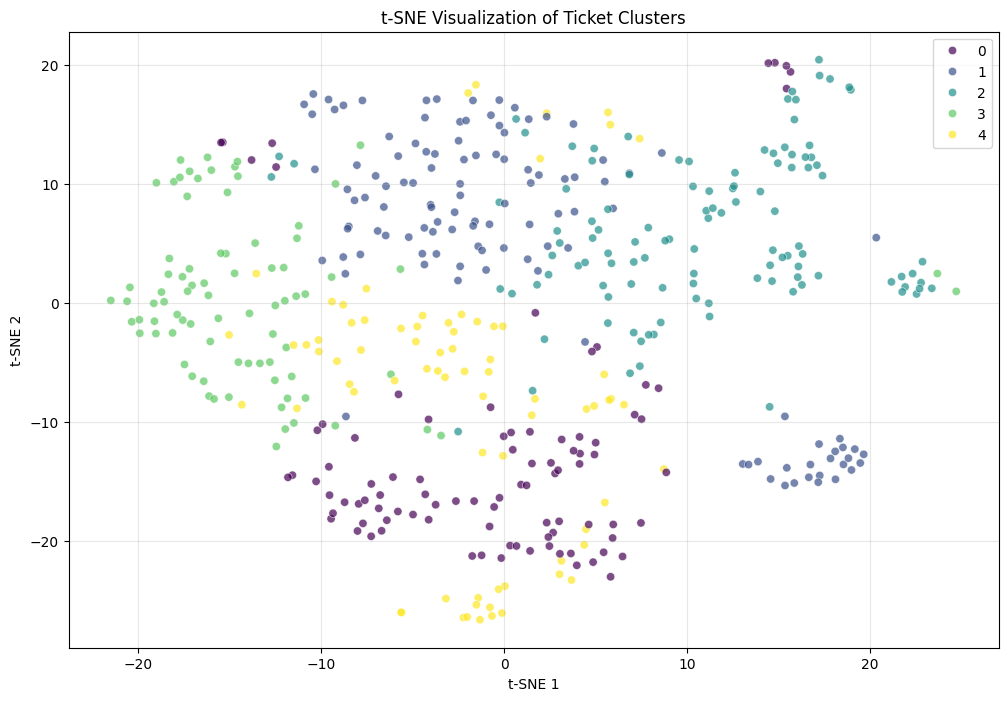

In [14]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.sparse import issparse
from sklearn.decomposition import TruncatedSVD

# 1. Prepare Data for t-SNE
# If X is sparse (TF-IDF), reduce dimensions first with TruncatedSVD for performance
if issparse(X):
    print("X is sparse. Reducing dimensions with TruncatedSVD before t-SNE...")
    svd = TruncatedSVD(n_components=min(50, X.shape[1]-1), random_state=42)
    X_for_tsne = svd.fit_transform(X)
else:
    X_for_tsne = X

# 2. Run t-SNE
print("Running t-SNE (this may take a moment)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_for_tsne)

# 3. Visualize
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=kmeans_model_sampled.labels_,
    palette='viridis',
    legend='full',
    alpha=0.7
)
plt.title('t-SNE Visualization of Ticket Clusters')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)
plt.show()

### Inter-Cluster Semantic Similarity
Quantifying the semantic overlap between identified clusters using Cosine Similarity of centroids.

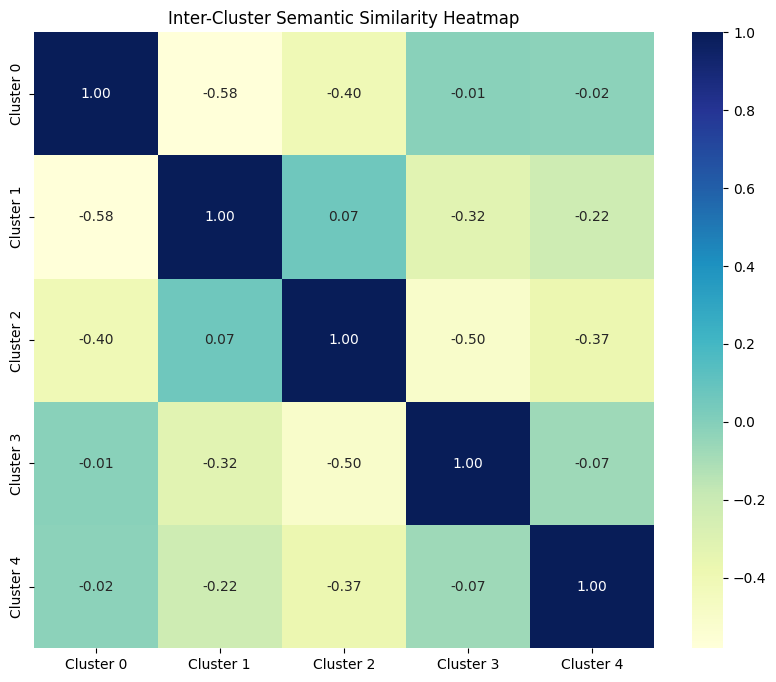

In [15]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.sparse import issparse

# 1. Calculate Centroids
labels = kmeans_model_sampled.labels_
unique_labels = np.unique(labels)
centroids = []

for label in unique_labels:
    mask = (labels == label)
    cluster_points = X[mask]
    if issparse(cluster_points):
        centroid = cluster_points.mean(axis=0).A1 # Convert sparse mean to 1D array
    else:
        centroid = cluster_points.mean(axis=0)
    centroids.append(centroid)

centroids = np.array(centroids)

# 2. Compute Cosine Similarity
similarity_matrix = cosine_similarity(centroids)

# 3. Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='YlGnBu',
    xticklabels=[f'Cluster {l}' for l in unique_labels],
    yticklabels=[f'Cluster {l}' for l in unique_labels]
)
plt.title('Inter-Cluster Semantic Similarity Heatmap')
plt.show()

In [16]:
# --- AUTO-LOGGING CELL (AUTOGENERATED) ---
import os
import pandas as pd

# 1. Define Run Metadata
log_data = {
    'Notebook_Name': 'ServiceTickets002 (Semantic)',
    'Features': 'SBERT / PCA / KMeans',
    'Clusters': optimal_k if 'optimal_k' in locals() else len(set(kmeans_model_sampled.labels_)) if 'kmeans_model_sampled' in locals() else 0,
    'Silhouette': silhouette_avg if 'silhouette_avg' in locals() else None,
    'Davies_Bouldin': davies_bouldin if 'davies_bouldin' in locals() else None,
    'Calinski_Harabasz': calinski_harabasz if 'calinski_harabasz' in locals() else None,
    'Inertia': inertia if 'inertia' in locals() else None
}

# 2. Append/Update Registry
csv_path = 'notebook_evaluations.csv'
if os.path.exists(csv_path):
    df_eval = pd.read_csv(csv_path)
    # Remove existing entry for this notebook to update it
    df_eval = df_eval[df_eval['Notebook_Name'] != log_data['Notebook_Name']]
    # Append the new run
    df_eval = pd.concat([df_eval, pd.DataFrame([log_data])], ignore_index=True)
else:
    df_eval = pd.DataFrame([log_data])

# Save registry
df_eval.to_csv(csv_path, index=False)
print(f"Success: Metrics for {log_data['Notebook_Name']} updated in 'notebook_evaluations.csv'.")


Success: Metrics for ServiceTickets002 (Semantic) updated in 'notebook_evaluations.csv'.
